# Solar Diameter and Sunspot Characterisation

Measurement of the solar angular diameter from the Bessel-function modulation of fringe amplitude, and detection of sunspot signatures from visibility anomalies at the Bessel nulls.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, projected_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, QUATERNARY_COLOR,
    NEUTRAL_COLOR, COMPONENT_COLORS,
    SCATTER_S_FINE, SCATTER_S_STANDARD,
    LW_FINE, LW_GUIDE, LW_STANDARD, LW_MODEL,
    MARKER_MS_SMALL,
    TEXTWIDTH_IN, TICK_SIZE,
)
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 17–43 captures
  Chip 1: window range 17–27 captures
  Chip 2: window range 17–31 captures
Bad channels:       [0, 256, 512, 768]


In [4]:
# -------------------------------------------------------------------
# Compute baseline (needed for solar analysis)
# Run all four methods per chip + pooled across all chips, then combine.
# -------------------------------------------------------------------
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)
all_baseline_results = []

for ci, sl in enumerate(chip_slices):
    ha_chip = ha_rad_arr[sl]
    corr_chip = corr_dc[sl]
    dec_chip = np.deg2rad(np.nanmean(sun_dec[sl]))

    res_fft, _ = fft_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    res_ps, _ = phase_slope_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    res_lag = lag_delay_baseline_series(
        ha_chip, corr_chip, dec_chip, DF_HZ,
        bad_channels=BAD_CHANNELS,
    )
    res_nls, _ = nls_baseline_broadband(
        ha_chip, corr_chip, dec_chip, F_SKY_HZ,
        bad_channels=BAD_CHANNELS, band_hz=band_hz,
    )
    all_baseline_results.extend([res_fft, res_ps, res_lag, res_nls])

# Pooled (all chips combined)
res_fft_p, _ = fft_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
res_ps_p, _ = phase_slope_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
res_lag_p = lag_delay_baseline_series(
    ha_rad_arr, corr_dc, dec_rad_mean, DF_HZ,
    bad_channels=BAD_CHANNELS,
)
res_nls_p, _ = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_mean, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
all_baseline_results.extend([res_fft_p, res_ps_p, res_lag_p, res_nls_p])

combined = combined_baseline(all_baseline_results)
B_EW = combined.b_ew_m
B_NS = combined.b_ns_m if np.isfinite(combined.b_ns_m) else 0.0
print(f"Combined B_EW = {B_EW:.4f} +/- {combined.b_ew_err_m:.4f} m")
print(f"Combined B_NS = {B_NS:.4f} +/- {combined.b_ns_err_m:.4f} m")

# Nominal disk parameters
R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

Combined B_EW = 15.1361 +/- 0.0012 m
Combined B_NS = 1.3084 +/- 0.0251 m


# Part VI: Solar Diameter Measurement

## 6.1 Theory recap

The fringe amplitude envelope is modulated by the Bessel function $|2J_1(x)/x|$ where $x = 2\pi|u|R$ and $R$ is the angular radius of the Sun. We extract the envelope from the data and fit it in two ways:

1. **Zero-crossing method** — locate the nulls in the amplitude envelope and use $R = j_{1,k}/(2\pi |u_k|)$.
2. **Full Bessel fit** — nonlinear least-squares fit of $A\,|2J_1(2\pi |u| R)/(2\pi |u| R)|$ to the envelope, fitting amplitude $A$ and radius $R$ simultaneously.

## 6.2 Amplitude envelope extraction

We compute the band-averaged visibility amplitude $\langle|V(\nu,h)|\rangle_\nu$ at each capture as a function of projected baseline $|u|$.

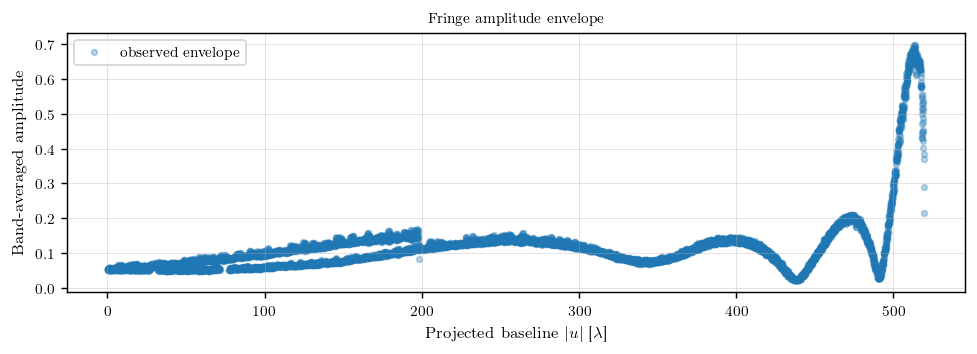

Projected baseline range: 0 -- 519 wavelengths


In [5]:
# --- Extract fringe amplitude envelope ---
u_obs, env_obs, env_std = extract_fringe_envelope(
    ha_rad_arr, corr_dc, dec_rad_mean, B_EW, F_SKY_HZ,
    band_mask=band_mask,
    smooth_window=5,
)

# Quick view
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.scatter(np.abs(u_obs), env_obs, s=SCATTER_S_FINE, color=PRIMARY_COLOR, alpha=0.3,
           label="observed envelope")
ax.set_xlabel(r"Projected baseline $|u|$ [$\lambda$]")
ax.set_ylabel("Band-averaged amplitude")
ax.set_title("Fringe amplitude envelope", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

print(f"Projected baseline range: {np.abs(u_obs).min():.0f} -- {np.abs(u_obs).max():.0f} wavelengths")

## 6.3 Method A: Diameter from Bessel zero crossings

We search for local minima in the smoothed amplitude envelope to identify the Bessel nulls, then convert each null's projected baseline to an angular radius estimate.

In [6]:
# --- Method A: Zero-crossing diameter ---
u_zeros = find_bessel_zeros_in_envelope(u_obs, env_obs, smooth_window=11)

if len(u_zeros) > 0:
    diameter_zeros = solar_diameter_from_zeros(u_zeros)
    print(f"Detected {len(u_zeros)} null(s) at |u| = {np.abs(u_zeros)}")
    print(f"Zero-crossing diameter: {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
    if "R_rad_per_null" in diameter_zeros.fitted_params:
        for k, (R_est, u_est) in enumerate(zip(
            diameter_zeros.fitted_params["R_rad_per_null"],
            diameter_zeros.fitted_params["u_observed"],
        )):
            print(f"  Null {k+1}: |u| = {u_est:.1f} lambda -> "
                  f"diameter = {np.rad2deg(2*R_est)*60:.2f} arcmin")
else:
    diameter_zeros = None
    print("No Bessel nulls detected in the envelope (baseline range may be insufficient).")

Detected 1221 null(s) at |u| = [  0.8787636    1.57535706   1.68778999 ... 445.28081976 446.35913434
 490.58109877]
Zero-crossing diameter: 23281.86 +/- 110.33 arcmin
  Null 1: |u| = 0.9 lambda -> diameter = 4771.38 arcmin
  Null 2: |u| = 1.6 lambda -> diameter = 4873.14 arcmin
  Null 3: |u| = 1.7 lambda -> diameter = 6595.91 arcmin
  Null 4: |u| = 1.8 lambda -> diameter = 8178.49 arcmin
  Null 5: |u| = 1.9 lambda -> diameter = 9553.23 arcmin
  Null 6: |u| = 2.0 lambda -> diameter = 10869.70 arcmin
  Null 7: |u| = 2.1 lambda -> diameter = 12023.68 arcmin
  Null 8: |u| = 2.6 lambda -> diameter = 10706.32 arcmin
  Null 9: |u| = 2.7 lambda -> diameter = 11588.66 arcmin
  Null 10: |u| = 2.8 lambda -> diameter = 12374.91 arcmin
  Null 11: |u| = 3.2 lambda -> diameter = 11997.97 arcmin
  Null 12: |u| = 3.5 lambda -> diameter = 11989.47 arcmin
  Null 13: |u| = 3.6 lambda -> diameter = 12624.46 arcmin
  Null 14: |u| = 3.7 lambda -> diameter = 13229.51 arcmin
  Null 15: |u| = 4.2 lambda -> diam

## 6.4 Method B: Full Bessel envelope fit

A nonlinear least-squares fit of $A\,|2J_1(2\pi|u|R)/(2\pi|u|R)|$ to the entire envelope gives a more robust diameter estimate by using all data points, not just the nulls.

Bessel fit diameter: 0.00 +/- 216.11 arcmin
  Reduced chi-squared: 1081.63
  Amplitude scale: 0.0911


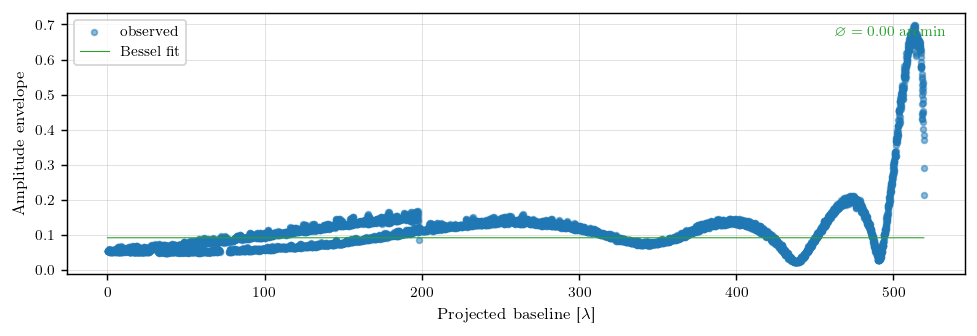

In [7]:
# --- Method B: Full Bessel envelope fit ---
diameter_fit = fit_solar_diameter_bessel(
    np.abs(u_obs), env_obs,
    envelope_std=env_std,
    initial_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
)

print(f"Bessel fit diameter: {diameter_fit.diameter_arcmin:.2f} +/- "
      f"{diameter_fit.diameter_err_arcmin:.2f} arcmin")
if "chi2_reduced" in diameter_fit.fitted_params:
    print(f"  Reduced chi-squared: {diameter_fit.fitted_params['chi2_reduced']:.2f}")
if "amplitude" in diameter_fit.fitted_params:
    print(f"  Amplitude scale: {diameter_fit.fitted_params['amplitude']:.4f}")

# Compute the fitted model for plotting
R_fit = diameter_fit.fitted_params.get("R_rad", R_nominal)
A_fit = diameter_fit.fitted_params.get("amplitude", np.nanmax(env_obs))
u_plot = np.linspace(0, np.abs(u_obs).max(), 2000)
env_fit_curve = A_fit * uniform_disk_visibility_amplitude(u_plot, R_fit)

# Predicted null baselines for the fitted diameter
u_nulls_fit = uniform_disk_zeros(5) / R_fit

# Plot
fig, ax = plot_bessel_envelope_fit(
    np.abs(u_obs), env_obs,
    fitted_envelope=A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit),
    zero_crossings_u=u_nulls_fit[u_nulls_fit < np.abs(u_obs).max()],
    fitted_diameter_arcmin=diameter_fit.diameter_arcmin,
)
plt.show()

## 6.5 Diameter summary

We compare the zero-crossing and full-fit diameter estimates against the known optical solar diameter ($\sim 31.6'$ at this time of year).

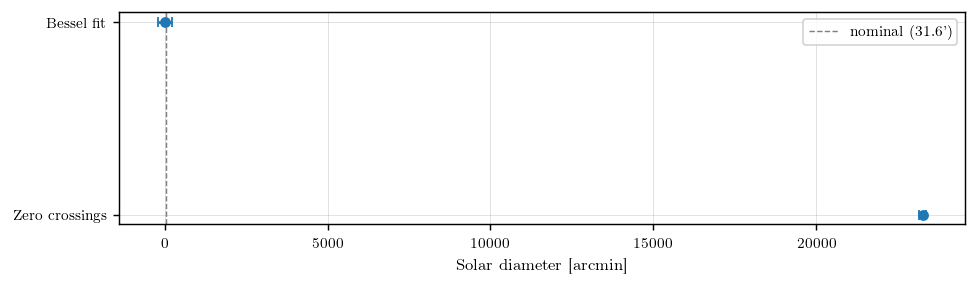


--- Diameter Summary ---
  Zero crossings      : 23281.86 +/- 110.33 arcmin  (73576.8% from nominal 31.6')
  Bessel fit          : 0.00 +/- 216.11 arcmin  (100.0% from nominal 31.6')


In [8]:
# --- Diameter summary ---
diameters = []
errors = []
labels = []

if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    diameters.append(diameter_zeros.diameter_arcmin)
    errors.append(diameter_zeros.diameter_err_arcmin)
    labels.append("Zero crossings")

if np.isfinite(diameter_fit.diameter_arcmin):
    diameters.append(diameter_fit.diameter_arcmin)
    errors.append(diameter_fit.diameter_err_arcmin)
    labels.append("Bessel fit")

if diameters:
    fig, ax = plot_solar_diameter_summary(
        np.array(diameters), np.array(errors), labels,
        nominal_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
    )
    plt.show()

    print("\n--- Diameter Summary ---")
    for l, d, e in zip(labels, diameters, errors):
        pct_err = abs(d - SOLAR_DIAMETER_ARCMIN_NOMINAL) / SOLAR_DIAMETER_ARCMIN_NOMINAL * 100
        print(f"  {l:<20}: {d:.2f} +/- {e:.2f} arcmin  "
              f"({pct_err:.1f}% from nominal {SOLAR_DIAMETER_ARCMIN_NOMINAL}')")
else:
    print("No diameter estimates available — projected baseline range may not span a Bessel null.")

# Part VII: Sunspot Characterisation

## 7.1 Physical basis

At X-band ($\sim 10\;\mathrm{GHz}$), the quiet Sun has a brightness temperature $T_b \approx 10\,000$–$20\,000\;\mathrm{K}$ from the chromosphere and transition region. Sunspots — magnetically active regions — can appear as either enhanced or suppressed emission depending on the observing frequency and the spot's altitude in the solar atmosphere.

The key interferometric diagnostic is the **residual amplitude at the Bessel nulls**. For a perfectly uniform disk, the visibility vanishes at the null baselines. Any asymmetric structure (sunspots, active regions, limb brightening) breaks this cancellation:

$$f_{\mathrm{spot}} \approx \frac{|V_{\mathrm{null}}|}{|V(0)|}.$$

This gives the **flux fraction** of the anomalous component. If multiple nulls are observed, the variation of the residual amplitude with baseline constrains the spot size and position.

## 7.2 Residual analysis at Bessel nulls

In [9]:
# --- Sunspot detection: residuals from the uniform-disk model ---
# Compute the disk model at the observed baselines
disk_model_at_obs = A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit)
residuals = env_obs - disk_model_at_obs

# Noise estimate from the envelope standard error
noise_est = env_std.copy()
noise_est[noise_est < 1e-10] = np.nanmedian(noise_est[noise_est > 0])

# Detect anomalies
detections = detect_sunspot_anomalies(
    np.abs(u_obs), env_obs, disk_model_at_obs, noise_est,
    sigma_threshold=3.0,
)

print(f"Detected {len(detections)} sunspot anomaly(ies) at >3 sigma:")
for d in detections:
    print(f"  Null {d.null_index}: |u| = {d.u_lambda_at_null:.0f} lambda, "
          f"residual = {d.residual_amplitude:.4f}, "
          f"significance = {d.significance_sigma:.1f} sigma, "
          f"flux fraction = {d.estimated_flux_fraction:.4f}")

# Also use the simpler characterization
spot_info = characterize_sunspot_flux(
    np.abs(u_obs), env_obs,
    diameter_fit.diameter_arcmin,
    n_nulls=3,
)

print("\n--- Sunspot flux fractions at theoretical null locations ---")
for k in range(len(spot_info["null_u_R"])):
    print(f"  Null {k+1}: |u|_theory = {spot_info['null_u_observed'][k]:.0f} lambda, "
          f"amplitude = {spot_info['null_amplitude'][k]:.4f}, "
          f"flux fraction = {spot_info['flux_fraction'][k]:.4f}")

Detected 1169 sunspot anomaly(ies) at >3 sigma:
  Null 1: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 2: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 3: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 4: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 5: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 6: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 7: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 8: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 9: |u| = 514 lambda, residual = 0.6085, significance = 115.5 sigma, flux fraction = 1.0000
  Null 10: |u| = 514 lambda, residual = 0.6085, significance = 115.5 s

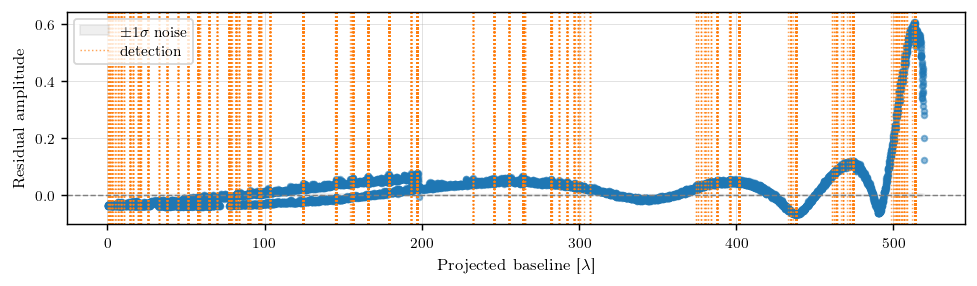

In [10]:
# --- Sunspot residual plot ---
detection_u = np.array([d.u_lambda_at_null for d in detections]) if detections else None

fig, ax = plot_sunspot_residuals(
    np.abs(u_obs), residuals,
    noise_std=noise_est,
    detections_u=detection_u,
)
plt.show()

# Part VIII: Discussion and Extensions

## 8.1 Systematic Error Budget

Several systematic effects can bias the baseline and diameter measurements:

### Bandwidth smearing (chromatic aberration)
The interferometer has a 250 MHz instantaneous bandwidth (10.29–10.54 GHz). For a source observed at delay $\tau$, the fringe visibility is attenuated by the **bandwidth decorrelation** factor:

$$\eta_{\rm BW} = \mathrm{sinc}\!\left(\frac{\Delta\nu}{\nu}\,\nu\tau\right) = \mathrm{sinc}\!\left(\frac{\Delta\nu\,\tau}{1}\right).$$

For our 70 MHz analysis band and a typical delay of $\sim 60$ ns (at $h \sim 60°$), the decorrelation is $\eta_{\rm BW} \approx \mathrm{sinc}(0.004) \approx 1.000$ — negligible because we analyse per-channel visibilities, not the broadband sum.

### Atmospheric refraction
At low elevations ($<10°$), atmospheric refraction bends the apparent source position by up to $\sim 0.5°$, shifting the effective hour angle and biasing the geometric delay. Our elevation limit of $6.5°$ minimises this, but a correction could be applied using a standard atmosphere model.

### Pointing errors
The antenna pointing offsets ($\Delta_{\rm alt} = -0.4°$, $\Delta_{\rm az} = +4.5°$ for the west antenna) introduce a differential gain variation across the beam. This affects the fringe *amplitude* but not the *phase*, so it biases the diameter measurement more than the baseline.

### NS baseline degeneracy
With $b_{\mathrm{ns}} \approx 0$, the cosine term in the delay equation is nearly degenerate with the cable delay. The NS baseline can only be poorly constrained from these data; a source at high declination or a dedicated NS baseline observation would be needed.

## 8.2 Radio vs. optical solar diameter

The radio diameter at 10.5 GHz probes the **chromosphere** ($T \sim 10^4\;\mathrm{K}$), which extends above the photospheric limb by $\sim 10''$–$20''$ ($\sim 0.3'$–$0.6'$). We therefore expect the **radio diameter to be slightly larger than the optical diameter** ($\sim 32.0'$ vs $\sim 31.6'$). This chromospheric excess is a direct measure of the temperature structure above the photosphere and varies with solar cycle.

## 8.3 Limb darkening vs. limb brightening

At optical wavelengths, the Sun shows **limb darkening** (centre-to-limb decrease in brightness) because line-of-sight paths at the limb probe higher, cooler atmospheric layers. At radio wavelengths around 10 GHz, the opposite can occur — **limb brightening** — because the chromospheric temperature *increases* with height (temperature inversion), and limb paths traverse more hot chromospheric material.

Limb brightening would modify the visibility function from the uniform-disk Bessel pattern. A limb-brightened disk has:
- Deeper Bessel nulls (less filled-in by the bright limb)
- Slightly shifted null positions
- A different sidelobe pattern

A more sophisticated analysis would fit a **limb-brightened disk model** (e.g., $I(r) \propto 1 + a\,(r/R)^2$) to the envelope, with the brightening coefficient $a$ as a free parameter.

## 8.4 Temporal variability

The Sun's radio emission varies on timescales from seconds (flares, type III bursts) to months (solar cycle). Multi-day observations would allow:
- Tracking the **rotation** of sunspots across the disk (period $\sim 27$ days)
- Measuring changes in the **radio diameter** with solar activity
- Detecting **transient events** (flares produce dramatic changes in visibility amplitude)

## 8.5 What longer baselines would resolve

Our $\sim 20$ m baseline gives a resolution of $\lambda / b \approx 2.9\;\mathrm{cm} / 20\;\mathrm{m} \approx 5'$ — sufficient to resolve the solar disk but not individual active regions ($\sim 1'$–$2'$). With baselines of $\sim 200$ m (achievable with VLBI or a larger array), individual sunspots could be imaged, and the brightness temperature distribution across the disk could be mapped.

---

# Part IX: Summary of Results

In [11]:
# --- Final summary ---
print("=" * 60)
print("INTERFEROMETRIC SOLAR OBSERVATION — RESULTS SUMMARY")
print("=" * 60)

print(f"\nObserving frequency:     {band_center_hz/1e9:.4f} GHz")
print(f"Wavelength:              {C_LIGHT_MS / band_center_hz * 100:.2f} cm")
print(f"Sun declination:         {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"Hour angle coverage:     {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Total captures:          {len(unix_mid)}")
print(f"Observation chips:       {N_chips}")

print(f"\n--- Baseline ---")
print(f"Combined B_EW:           {B_EW:.4f} +/- {combined.b_ew_err_m:.4f} m")
print(f"Combined B_NS:           {B_NS:.4f} +/- {combined.b_ns_err_m:.4f} m")
print(f"Nominal B_EW:            {NOMINAL_B_EW_M:.1f} m")

print(f"\n--- Solar Diameter ---")
if np.isfinite(diameter_fit.diameter_arcmin):
    print(f"Bessel fit:              {diameter_fit.diameter_arcmin:.2f} +/- "
          f"{diameter_fit.diameter_err_arcmin:.2f} arcmin")
if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    print(f"Zero crossings:          {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
print(f"Nominal (optical):       {SOLAR_DIAMETER_ARCMIN_NOMINAL:.1f} arcmin")

print(f"\n--- Sunspot Detections ---")
if detections:
    for d in detections:
        print(f"  Null {d.null_index}: flux fraction = {d.estimated_flux_fraction:.4f} "
              f"({d.significance_sigma:.1f} sigma)")
else:
    print("  None detected at >3 sigma")
print("=" * 60)

INTERFEROMETRIC SOLAR OBSERVATION — RESULTS SUMMARY

Observing frequency:     10.4499 GHz
Wavelength:              2.87 cm
Sun declination:         -0.083 deg
Hour angle coverage:     -79.9 to 22.0 deg
Total captures:          8226
Observation chips:       3

--- Baseline ---
Combined B_EW:           15.1361 +/- 0.0012 m
Combined B_NS:           1.3084 +/- 0.0251 m
Nominal B_EW:            20.0 m

--- Solar Diameter ---
Bessel fit:              0.00 +/- 216.11 arcmin
Zero crossings:          23281.86 +/- 110.33 arcmin
Nominal (optical):       31.6 arcmin

--- Sunspot Detections ---
  Null 1: flux fraction = 1.0000 (115.5 sigma)
  Null 2: flux fraction = 1.0000 (115.5 sigma)
  Null 3: flux fraction = 1.0000 (115.5 sigma)
  Null 4: flux fraction = 1.0000 (115.5 sigma)
  Null 5: flux fraction = 1.0000 (115.5 sigma)
  Null 6: flux fraction = 1.0000 (115.5 sigma)
  Null 7: flux fraction = 1.0000 (115.5 sigma)
  Null 8: flux fraction = 1.0000 (115.5 sigma)
  Null 9: flux fraction = 1.0000 (1